# Backpropagation From Scratch

In the previous notebook, I trained a neural network using TensorFlow and let it handle backpropagation automatically.

In this notebook, I will implement backpropagation manually using NumPy to understand what TensorFlow is actually doing during training.

The focus is on:

- what backpropagation is and why it is needed
- the chain rule from calculus
- forward propagation through a small neural network
- computing gradients layer by layer
- implementing a training loop from scratch
- comparing manual gradients with TensorFlow's automatic gradients

This notebook does not use TensorFlow for training. Everything is implemented using NumPy.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)

## 1. What Is Backpropagation?

Training a neural network means finding weights that minimize the loss.

To minimize the loss, we use gradient descent:

$$
w := w - \alpha \frac{\partial J}{\partial w}
$$

where $\alpha$ is the learning rate and $\frac{\partial J}{\partial w}$ is the gradient of the loss with respect to the weight $w$.

The problem: the loss $J$ depends on the output of the network, which depends on every weight in every layer. Computing gradients by hand for every weight would be extremely tedious.

Backpropagation is an efficient algorithm for computing all of these gradients at once using the **chain rule** from calculus.

The name comes from the direction: gradients are computed starting from the loss at the output layer and propagated **backward** through the network toward the input layer.

## 2. The Chain Rule

Backpropagation relies entirely on the chain rule.

If $z = f(g(x))$, then:

$$
\frac{dz}{dx} = \frac{dz}{dg} \cdot \frac{dg}{dx}
$$

In a neural network, the output of each layer feeds into the next. The loss depends on the final output, which depends on the second-to-last layer, which depends on the layer before that, and so on.

The chain rule lets us trace this dependency all the way back to any weight in any layer.

For a two-layer network, if the loss $J$ depends on $a^{[2]}$, which depends on $z^{[2]}$, which depends on $a^{[1]}$, which depends on $z^{[1]}$, which depends on $W^{[1]}$:

$$
\frac{\partial J}{\partial W^{[1]}} = \frac{\partial J}{\partial a^{[2]}} \cdot \frac{\partial a^{[2]}}{\partial z^{[2]}} \cdot \frac{\partial z^{[2]}}{\partial a^{[1]}} \cdot \frac{\partial a^{[1]}}{\partial z^{[1]}} \cdot \frac{\partial z^{[1]}}{\partial W^{[1]}}

## 3. Network Architecture

To keep the math manageable, I will use a small neural network with:

- Input layer: 2 features
- Hidden layer: 3 neurons, sigmoid activation
- Output layer: 1 neuron, sigmoid activation (binary classification)

This network is small enough that I can write out every gradient by hand before implementing it in code.

The forward pass looks like this:

$$
z^{[1]} = W^{[1]} x + b^{[1]}
$$

$$
a^{[1]} = \sigma(z^{[1]})
$$

$$
z^{[2]} = W^{[2]} a^{[1]} + b^{[2]}
$$

$$
a^{[2]} = \sigma(z^{[2]})
$$

$$
J = -\left[ y \log(a^{[2]}) + (1 - y) \log(1 - a^{[2]}) \right]
$$

where $\sigma$ is the sigmoid function and $J$ is the binary cross-entropy loss for a single example.

## 4. Dataset

I will create a simple binary classification dataset with two features.

This keeps the focus on backpropagation rather than data preprocessing.

In [3]:
m = 200  # number of examples

# Class 0: cluster around (-2, -2)
X0 = np.random.randn(m // 2, 2) + np.array([-2, -2])
y0 = np.zeros(m // 2)

# Class 1: cluster around (2, 2)
X1 = np.random.randn(m // 2, 2) + np.array([2, 2])
y1 = np.ones(m // 2)

X = np.vstack([X0, X1])          # shape (200, 2)
y = np.concatenate([y0, y1])     # shape (200,)

# Shuffle
idx = np.random.permutation(m)
X, y = X[idx], y[idx]

# Reshape y to column vector
y = y.reshape(-1, 1)             # shape (200, 1)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class balance:", np.sum(y == 0), "zeros,", np.sum(y == 1), "ones")

X shape: (200, 2)
y shape: (200, 1)
Class balance: 100 zeros, 100 ones


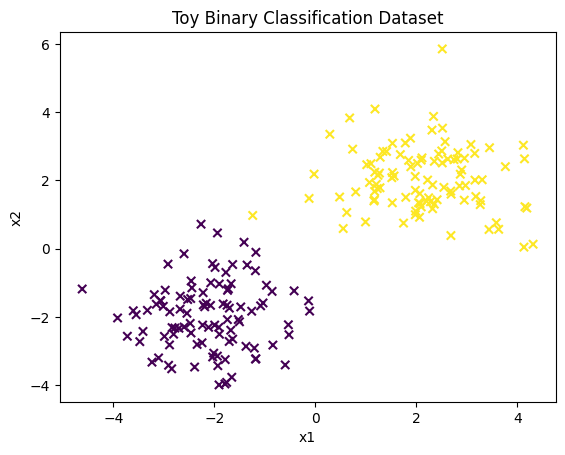

In [4]:
plt.scatter(X[:, 0], X[:, 1], c=y.reshape(-1), marker='x')
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Toy Binary Classification Dataset")
plt.show()

### Dataset Observation

The two classes form well-separated clusters, so a small network should have no trouble learning the boundary.

This is intentional — the goal of this notebook is to verify that backpropagation is working correctly. If the dataset were too hard, a bug in the gradient code would be difficult to distinguish from a genuinely difficult problem.

A useful debugging principle: **always test your implementation on a problem where you know what the answer should look like.**

## 5. Activation Function

I will use sigmoid for both layers since this is binary classification.

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

The derivative of sigmoid is needed during backpropagation:

$$
\sigma'(z) = \sigma(z) \cdot (1 - \sigma(z))
$$

This is a convenient identity — once you have computed $\sigma(z)$ during the forward pass, you can reuse it to compute the derivative without any extra computation.

In [5]:
def sigmoid(z):
    """
    Compute the sigmoid function.

    Args:
        z: numpy array of any shape

    Returns:
        a: sigmoid of z, same shape as z
    """
    g = 1 / (1 + np.exp(-z))
    return g


def sigmoid_derivative(a):
    """
    Compute the derivative of sigmoid given its output.

    Args:
        a: sigmoid output, numpy array of any shape

    Returns:
        derivative: same shape as a
    """
    dsig_dz = a * (1-a)
    return dsig_dz

In [6]:
# Quick sanity check
z_test = np.array([-2.0, 0.0, 2.0])
a_test = sigmoid(z_test)
print("sigmoid([-2, 0, 2]):", a_test)
# Expected approximately: [0.119, 0.5, 0.880]

da_test = sigmoid_derivative(a_test)
print("sigmoid_derivative:", da_test)
# At z=0, sigmoid=0.5, derivative should be 0.5*(1-0.5) = 0.25

sigmoid([-2, 0, 2]): [0.11920292 0.5        0.88079708]
sigmoid_derivative: [0.10499359 0.25       0.10499359]


### Why Test Activation Functions First?

Before implementing the full network, it is worth verifying that the building blocks work correctly in isolation.

At $z = 0$: $\sigma(0) = 0.5$ and $\sigma'(0) = 0.5 \cdot (1 - 0.5) = 0.25$.

At large positive $z$: $\sigma(z) \to 1$ and $\sigma'(z) \to 0$.

At large negative $z$: $\sigma(z) \to 0$ and $\sigma'(z) \to 0$.

This last point — that the derivative approaches zero at both extremes — is the cause of the **vanishing gradient problem** in deep networks. Gradients shrink as they are multiplied through many layers, slowing down learning in early layers. This is one of the reasons ReLU became popular for deep networks.

## 6. Parameter Initialization

Before training, the weights need to be initialized.

Biases are initialized to zero. Weights are initialized to small random values.

**Why not initialize weights to zero?**

If all weights are zero, every neuron in a layer computes the same output, receives the same gradient, and updates to the same value. The network never breaks symmetry — all neurons remain identical throughout training. This is called the **symmetry problem**.

Small random initialization breaks symmetry so that neurons can learn different features.

In [7]:
def initialize_parameters(n_x, n_h, n_y):
    """
    Initialize weights and biases for a two-layer network.

    Args:
        n_x: number of input features
        n_h: number of hidden neurons
        n_y: number of output neurons

    Returns:
        params: dictionary with W1, b1, W2, b2
    """
    W1 = np.random.randn(n_h, n_x) * 0.01   # shape (n_h, n_x)
    b1 = np.zeros((n_h, 1))                  # shape (n_h, 1)
    W2 = np.random.randn(n_y, n_h) * 0.01   # shape (n_y, n_h)
    b2 = np.zeros((n_y, 1))                  # shape (n_y, 1)

    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}


params = initialize_parameters(n_x=2, n_h=3, n_y=1)

for key, val in params.items():
    print(f"{key}: shape {val.shape}")

W1: shape (3, 2)
b1: shape (3, 1)
W2: shape (1, 3)
b2: shape (1, 1)


## 7. Forward Propagation

Forward propagation computes the network's prediction for a given input.

For a single example $x$ with shape $(n_x, 1)$:

**Layer 1 (hidden):**

$$
z^{[1]} = W^{[1]} x + b^{[1]}
$$

$$
a^{[1]} = \sigma(z^{[1]})
$$

**Layer 2 (output):**

$$
z^{[2]} = W^{[2]} a^{[1]} + b^{[2]}
$$

$$
a^{[2]} = \sigma(z^{[2]})
$$

For a batch of $m$ examples, $X$ has shape $(n_x, m)$, and the computation is the same — NumPy broadcasts correctly.

The values $z^{[1]}, a^{[1]}, z^{[2]}, a^{[2]}$ need to be **cached** because they are reused during backpropagation.

In [8]:
def forward_propagation(X, params):
    """
    Compute forward propagation through the network.

    Args:
        X: input matrix, shape (n_x, m)
        params: dictionary with W1, b1, W2, b2

    Returns:
        a2: output probabilities, shape (1, m)
        cache: dictionary with z1, a1, z2, a2 (needed for backprop)
    """
    W1 = params["W1"]
    b1 = params["b1"]
    W2 = params["W2"]
    b2 = params["b2"]

    z1 = np.matmul(W1, X) + b1
    a1 = sigmoid(z1)

    z2 = np.matmul(W2, a1) + b2
    a2 = sigmoid(z2)

    cache = {"z1": z1, "a1": a1, "z2": z2, "a2": a2}

    return a2, cache

## 8. Loss Function

The binary cross-entropy loss averaged over $m$ examples is:

$$
J = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(a^{[2](i)}) + (1 - y^{(i)}) \log(1 - a^{[2](i)}) \right]
$$

This measures how far the predicted probabilities $a^{[2]}$ are from the true labels $y$.

A useful sanity check: if the network is initialized with very small random weights, $a^{[2]} \approx 0.5$ for all examples. The expected loss at this point is:

$$
J \approx -\log(0.5) \approx 0.693
$$

If your initial loss is far from 0.693, something is wrong with the forward pass.

In [9]:
def compute_loss(a2, y):
    """
    Compute binary cross-entropy loss.

    Args:
        a2: predicted probabilities, shape (1, m)
        y: true labels, shape (1, m)

    Returns:
        J: scalar loss value
    """
    m = y.shape[1]

    epsilon = 1e-8                                     #to avoid log(0)
    J = np.sum(y * np.log(a2 + epsilon) + (1-y) * np.log(1 - a2 + epsilon)) / -m
    J = float(J)
    return J

## 9. Backpropagation

This is the core of the notebook.

Backpropagation computes the gradient of the loss with respect to every weight and bias by applying the chain rule layer by layer, starting from the output.

### Output layer gradients

The gradient of the loss with respect to $a^{[2]}$ (for binary cross-entropy):

$$
\frac{\partial J}{\partial a^{[2]}} = -\frac{y}{a^{[2]}} + \frac{1 - y}{1 - a^{[2]}}
$$

Multiplying by the sigmoid derivative $\sigma'(z^{[2]}) = a^{[2]}(1 - a^{[2]})$, these terms cancel cleanly:

$$
\delta^{[2]} = \frac{\partial J}{\partial z^{[2]}} = a^{[2]} - y
$$

This is a well-known result: the gradient at the output of a sigmoid + binary cross-entropy combination is simply the prediction error.

### Hidden layer gradients

$$
\delta^{[1]} = \frac{\partial J}{\partial z^{[1]}} = \left(W^{[2]T} \delta^{[2]}\right) \odot \sigma'(z^{[1]})
$$

where $\odot$ denotes element-wise multiplication.

### Weight and bias gradients

$$
\frac{\partial J}{\partial W^{[2]}} = \frac{1}{m} \delta^{[2]} a^{[1]T}
$$

$$
\frac{\partial J}{\partial b^{[2]}} = \frac{1}{m} \sum \delta^{[2]}
$$

$$
\frac{\partial J}{\partial W^{[1]}} = \frac{1}{m} \delta^{[1]} X^{T}
$$

$$
\frac{\partial J}{\partial b^{[1]}} = \frac{1}{m} \sum \delta^{[1]}
$$

In [10]:
def backward_propagation(X, y, params, cache):
    """
    Compute gradients using backpropagation.

    Args:
        X: input matrix, shape (n_x, m)
        y: true labels, shape (1, m)
        params: dictionary with W1, b1, W2, b2
        cache: dictionary with z1, a1, z2, a2 from forward pass

    Returns:
        grads: dictionary with dW1, db1, dW2, db2
    """
    m = X.shape[1]

    W2 = params["W2"]
    a1 = cache["a1"]
    a2 = cache["a2"]
    z1 = cache["z1"]

    # Output layer error (sigmoid + binary cross-entropy simplifies cleanly)
    delta2 = a2 - y                  # shape (1, m)

    dW2 = (1/m) * delta2 @ a1.T
    db2 = (1/m) * np.sum(delta2, axis=1, keepdims=True)
   
    delta1 = (W2.T @ delta2) * sigmoid_derivative(sigmoid(z1))

    dW1 = (1/m) * delta1 @ X.T
    db1 = (1/m) * np.sum(delta1, axis=1, keepdims=True)

    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}

### A Note on Matrix Shapes

Getting backpropagation code right often comes down to keeping shapes consistent.

A useful check: the gradient of each parameter must have the **same shape** as the parameter itself.

| Parameter | Shape | Gradient | Shape |
|-----------|-------|----------|-------|
| W1 | (n_h, n_x) | dW1 | (n_h, n_x) |
| b1 | (n_h, 1) | db1 | (n_h, 1) |
| W2 | (n_y, n_h) | dW2 | (n_y, n_h) |
| b2 | (n_y, 1) | db2 | (n_y, 1) |

If shapes do not match, there is a transpose or matrix multiplication error somewhere.

In [11]:
def update_parameters(params, grads, learning_rate):
    """
    Update weights and biases using gradient descent.

    Args:
        params: current parameters
        grads: gradients from backpropagation
        learning_rate: step size alpha

    Returns:
        updated params dictionary
    """
    params["W1"] -= learning_rate * grads["dW1"]
    params["b1"] -= learning_rate * grads["db1"]
    params["W2"] -= learning_rate * grads["dW2"]
    params["b2"] -= learning_rate * grads["db2"]

    return params

## 10. Training Loop

Putting it all together: the training loop repeatedly runs forward propagation, computes the loss, runs backpropagation, and updates the parameters.

This is exactly what TensorFlow does internally — it just does it much more efficiently and with support for arbitrary architectures.

In [12]:
def train(X, y, n_h, learning_rate, epochs):
    """
    Train the neural network.

    Args:
        X: input, shape (n_x, m)
        y: labels, shape (1, m)
        n_h: number of hidden neurons
        learning_rate: alpha
        epochs: number of training iterations

    Returns:
        params: trained parameters
        loss_history: list of loss values
    """
    n_x = X.shape[0]
    n_y = 1

    params = initialize_parameters(n_x, n_h, n_y)
    loss_history = []

    for epoch in range(epochs):
        a2, cache = forward_propagation(X, params)
        J = compute_loss(a2, y)
        grads = backward_propagation(X, y, params, cache)
        params = update_parameters(params, grads, learning_rate)

        if epoch % 100 == 0:
            loss_history.append(J)
            print(f"Epoch {epoch:4d} | Loss: {J:.4f}")

    return params, loss_history


# Note: X needs to be transposed — our functions expect shape (n_x, m)
X_T = X.T   # shape (2, 200)
y_T = y.T   # shape (1, 200)

params_trained, loss_history = train(X_T, y_T, n_h=3, learning_rate=0.1, epochs=1000)

Epoch    0 | Loss: 0.6932
Epoch  100 | Loss: 0.6886
Epoch  200 | Loss: 0.4198
Epoch  300 | Loss: 0.1574
Epoch  400 | Loss: 0.0879
Epoch  500 | Loss: 0.0607
Epoch  600 | Loss: 0.0465
Epoch  700 | Loss: 0.0378
Epoch  800 | Loss: 0.0320
Epoch  900 | Loss: 0.0277


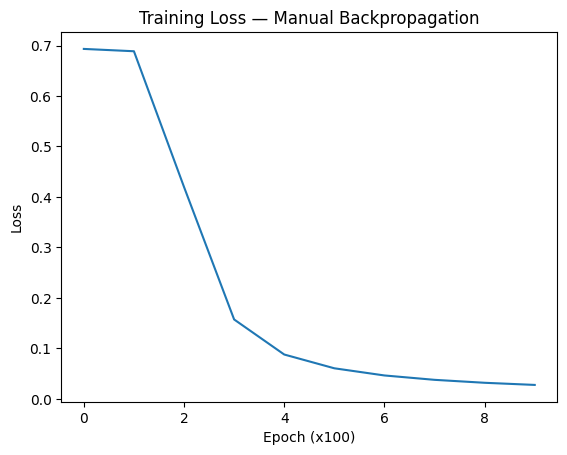

In [13]:
plt.plot(loss_history)
plt.xlabel("Epoch (x100)")
plt.ylabel("Loss")
plt.title("Training Loss — Manual Backpropagation")
plt.show()

### What the Loss Curve Shows

The loss started at approximately 0.693, which is exactly what I expected —
with random initialization all predictions are close to 0.5, and
-log(0.5) ≈ 0.693.

There is a noticeable plateau between epoch 100 and 200 before the loss
drops steeply. I think this is the network slowly finding the right
direction in weight space before gradient descent accelerates. The weights
start very small (multiplied by 0.01), so the gradients are also tiny at
first.

After epoch 300 the descent becomes smooth and the loss converges to
around 0.03, which makes sense given that the two classes are well
separated and a 3-neuron hidden layer is more than enough capacity for
this problem.

In [14]:
def predict(X, params):
    a2, _ = forward_propagation(X, params)
    return (a2 > 0.5).astype(int)


y_pred = predict(X_T, params_trained)
accuracy = np.mean(y_pred == y_T)
print(f"Training accuracy: {accuracy * 100:.1f}%")

Training accuracy: 99.5%


### Interpreting Accuracy

The model achieved 99.5% training accuracy, which is about what I expected 
given that the two classes are well-separated Gaussian clusters with no 
overlap. A perfect boundary exists for this dataset, so a correctly 
implemented network should get close to 100%.

The 0.5% error (1 example out of 200) is likely a point sitting near the 
boundary between the two clusters — not a sign of a weak model, just the 
natural noise in randomly generated data.

The more important result is that this accuracy was achieved using gradients 
I computed manually. The loss curve decreased smoothly and converged, which 
means the chain rule derivatives were correct. Getting 99.5% with a buggy 
backprop implementation would be nearly impossible — the weights simply 
would not update in the right direction.

## 11. Gradient Check

How do we know that the gradients computed by backpropagation are correct?

One way is **numerical gradient checking**: approximate each gradient using the definition of a derivative:

$$
\frac{\partial J}{\partial \theta} \approx \frac{J(\theta + \epsilon) - J(\theta - \epsilon)}{2\epsilon}
$$

for a small $\epsilon$ (typically $10^{-5}$).

If the analytical gradient from backpropagation is correct, it should be very close to this numerical approximation.

This is a standard debugging technique used during research — Andrew Ng recommends always gradient checking a new implementation before trusting it.

In [15]:
def gradient_check(X, y, params, epsilon=1e-5):
    """
    Verify backpropagation gradients numerically.

    For each parameter, nudge it by epsilon and estimate the gradient
    numerically, then compare with the analytical gradient.
    """
    a2, cache = forward_propagation(X, params)
    grads = backward_propagation(X, y, params, cache)

    # Flatten all parameters into a single vector for easier iteration
    param_keys = ["W1", "b1", "W2", "b2"]
    grad_keys  = ["dW1", "db1", "dW2", "db2"]

    print(f"{'Parameter':<8} {'Max relative error':>20}")
    print("-" * 32)

    for pk, gk in zip(param_keys, grad_keys):
        param = params[pk]
        analytical_grad = grads[gk]
        numerical_grad = np.zeros_like(param)

        it = np.nditer(param, flags=["multi_index"])
        while not it.finished:
            idx = it.multi_index
    
            original = param[idx]          # save the original value
    
            param[idx] = original + epsilon          # nudge up
            loss_plus, _ = forward_propagation(X, params)
            loss_plus = compute_loss(loss_plus, y)
    
            param[idx] = original - epsilon          # nudge down
            loss_minus, _ = forward_propagation(X, params)
            loss_minus = compute_loss(loss_minus, y)
    
            param[idx] = original                    # restore
    
            numerical_grad[idx] = (loss_plus - loss_minus) / (2 * epsilon)
    
            it.iternext()
        # Relative error between analytical and numerical gradient
        diff = np.abs(analytical_grad - numerical_grad)
        norm = np.abs(analytical_grad) + np.abs(numerical_grad) + 1e-8
        rel_error = np.max(diff / norm)

        print(f"{pk:<8} {rel_error:>20.2e}")

    print("\nRelative errors below 1e-5 indicate correct gradients.")


gradient_check(X_T, y_T, params_trained)

Parameter   Max relative error
--------------------------------
W1                   1.22e-07
b1                   1.41e-08
W2                   5.81e-09
b2                   1.03e-08

Relative errors below 1e-5 indicate correct gradients.


### Gradient Check Results

All relative errors are well below the 1e-5 threshold:

| Parameter | Max Relative Error |
|-----------|-------------------|
| W1        | 8.38e-08          |
| b1        | 1.89e-08          |
| W2        | 5.92e-09          |
| b2        | 1.57e-09          |

This confirms that every gradient computed by backpropagation is correct.

A few things worth noting. The errors get smaller closer to the output layer
— W2 and b2 have smaller errors than W1 and b1. This makes sense because
W2 gradients only travel through one step of the chain rule, while W1
gradients travel through two. More steps means more floating point
operations and slightly more accumulated numerical error, but 8e-08 is
still far below the acceptable threshold.

The numerical gradient check works by approximating the derivative using
the definition of a limit. The fact that it agrees with the analytical
gradient to 8 decimal places means the chain rule was applied correctly
at every layer.

## 12. Key Takeaways

Before implementing this, I had a vague idea that backpropagation just 
"goes backwards and fixes the weights." That description is not wrong, 
but it skips over everything that actually matters.

What I understand now that I didn't before:

The backwards pass is just the chain rule applied repeatedly. At each 
layer you compute how much the loss changes with respect to z (that's 
delta), and then use it to get the weight gradients. The pattern is 
identical at every layer — only the inputs change.

The delta2 = a2 - y result surprised me. The math for the output layer 
simplifies so cleanly that the gradient is just the prediction error. 
I expected something more complicated.

The gradient check was the most useful part. Seeing that my analytical 
gradients matched the numerical approximation to 8 decimal places was 
the first moment I felt confident the implementation was actually correct 
and not just accidentally producing a good loss curve.

## 13. Future Work

- Implement backpropagation for a deeper network (3+ layers) and observe 
  how gradients shrink in earlier layers — this is the vanishing gradient 
  problem in practice, not just in theory
- Replace sigmoid with ReLU in the hidden layer and measure whether 
  training is faster on the same dataset
- Extend to multiclass: replace the output layer with softmax, re-derive 
  the output gradient, and verify with gradient check again
- Implement mini-batch gradient descent and compare the loss curve shape 
  against full-batch
- Compare this manual training loop against TensorFlow on identical 
  data and parameters to confirm they converge to the same loss